# Modelo y Evaluación

# Modelo

## El modelo que vamos a aplicar es una red neuronal que aprende con el descenso del gradiente

En esta parte vamos a explicar en detalle todas las matemáticas que se aplican en el código del modelo. La red neuronal tiene $L$ capas en total: una capa de entrada, una o más capas ocultas y una capa de salida con una sola neurona (clasificación binaria).

---

## 1. Función de activación: Sigmoide

La función sigmoide transforma cualquier valor real en un número entre 0 y 1, lo que permite interpretar la salida como una probabilidad:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

**Propiedades clave:**
- $\sigma(z) \in (0, 1)$ para todo $z \in \mathbb{R}$
- $\sigma(0) = 0.5$
- Cuando $z \to +\infty$, $\sigma(z) \to 1$; cuando $z \to -\infty$, $\sigma(z) \to 0$

### Derivada de la sigmoide

La derivada de la sigmoide se puede expresar en función de sí misma, lo que es muy eficiente computacionalmente porque ya tenemos calculada la activación $a = \sigma(z)$ del forward pass:

$$
\sigma'(z) = \sigma(z)(1 - \sigma(z)) = a(1 - a)
$$

**Demostración:**

$$
\sigma'(z) = \frac{d}{dz}\left(\frac{1}{1+e^{-z}}\right) = \frac{e^{-z}}{(1+e^{-z})^2} = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \sigma(z)(1-\sigma(z))
$$

---

## 2. Inicialización de pesos y sesgos

Antes de entrenar, se inicializan los parámetros de cada capa $l$:

- **Pesos**: se inicializan con valores aleatorios pequeños siguiendo una distribución normal escalada:
  $$
  W^{[l]} \sim \mathcal{N}(0,\; 0.01) \quad \text{es decir, } W^{[l]} = 0.1 \cdot \mathcal{N}(0, 1)
  $$
  Se multiplica por 0.1 para que los pesos sean pequeños y las activaciones no se saturen en las zonas planas de la sigmoide (donde el gradiente es casi 0).

- **Sesgos**: se inicializan a cero:
  $$
  b^{[l]} = \mathbf{0}
  $$

Las dimensiones de los parámetros para cada capa $l$ son:
- $W^{[l]} \in \mathbb{R}^{n_l \times n_{l-1}}$ donde $n_l$ es el número de neuronas en la capa $l$
- $b^{[l]} \in \mathbb{R}^{n_l \times 1}$

---

## 3. Forward pass (propagación hacia adelante)

El forward pass calcula la salida de la red capa por capa. Para cada capa $l = 1, 2, \dots, L-1$ (donde $L$ es el número total de capas incluyendo entrada y salida):

### Paso 1: Combinación lineal
Se calcula la preactivación $z$ como el producto matricial de los pesos por las activaciones de la capa anterior, más el sesgo:

$$
z^{[l]} = W^{[l]} \cdot a^{[l-1]} + b^{[l]}
$$

donde $a^{[0]} = X^T$ es la entrada transpuesta (cada columna es un ejemplo).

### Paso 2: Activación
Se aplica la función sigmoide elemento a elemento:

$$
a^{[l]} = \sigma(z^{[l]})
$$

### Capa de salida (capa $L-1$ en el código)
La última capa tiene una sola neurona y también usa sigmoide:

$$
z^{[L-1]} = W^{[L-1]} \cdot a^{[L-2]} + b^{[L-1]}, \quad \hat{y} = a^{[L-1]} = \sigma(z^{[L-1]})
$$

La salida $\hat{y} \in (0,1)$ se interpreta como la probabilidad de pertenecer a la clase 1.

---

## 4. Función de coste: Entropía cruzada binaria

Para medir el error entre las predicciones $\hat{y}_i$ y las etiquetas reales $y_i$, se usa la entropía cruzada binaria:

$$
J(W, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i + \varepsilon) + (1 - y_i)\log(1 - \hat{y}_i + \varepsilon) \right]
$$

donde:
- $m$ es el número de ejemplos de entrenamiento
- $y_i \in \{0, 1\}$ es la etiqueta real del ejemplo $i$
- $\hat{y}_i = a^{[L-1]}_i$ es la predicción de la red para el ejemplo $i$
- $\varepsilon = 10^{-8}$ es un valor pequeño que se suma para **estabilidad numérica**, evitando calcular $\log(0)$ que sería $-\infty$

**Intuición del coste:**
- Si $y_i = 1$: el coste es $-\log(\hat{y}_i)$ → penaliza si $\hat{y}_i$ es cercano a 0
- Si $y_i = 0$: el coste es $-\log(1 - \hat{y}_i)$ → penaliza si $\hat{y}_i$ es cercano a 1

---

## 5. Backpropagation (propagación hacia atrás)

El objetivo del backpropagation es calcular los gradientes $\frac{\partial J}{\partial W^{[l]}}$ y $\frac{\partial J}{\partial b^{[l]}}$ para cada capa, necesarios para actualizar los pesos.

### Paso 1: Error en la capa de salida

Se calcula la derivada de la función de coste respecto a la activación de la salida:

$$
dA^{[L-1]} = a^{[L-1]} - y
$$

Esto es resultado de derivar la entropía cruzada respecto a $a^{[L-1]}$ y simplificar con la derivada de la sigmoide.

### Paso 2: Gradiente de la preactivación ($dZ$)

Para cada capa $l$, se multiplica $dA^{[l]}$ por la derivada de la sigmoide (elemento a elemento con $\odot$):

$$
dZ^{[l]} = dA^{[l]} \odot \sigma'(z^{[l]}) = dA^{[l]} \odot a^{[l]} \odot (1 - a^{[l]})
$$

### Paso 3: Gradientes de los pesos y sesgos

Con $dZ^{[l]}$ calculamos los gradientes que necesitamos:

$$
\frac{\partial J}{\partial W^{[l]}} = \frac{1}{m} \, dZ^{[l]} \cdot (a^{[l-1]})^T
$$

$$
\frac{\partial J}{\partial b^{[l]}} = \frac{1}{m} \sum_{\text{columnas}} dZ^{[l]}
$$

Se divide entre $m$ porque la función de coste promedia sobre todos los ejemplos.

### Paso 4: Propagar el error a la capa anterior

Para continuar el backpropagation hacia las capas más cercanas a la entrada ($l > 1$):

$$
dA^{[l-1]} = (W^{[l]})^T \cdot dZ^{[l]}
$$

Se repiten los pasos 2-4 para $l = L-1, L-2, \dots, 1$.

---

## 6. Actualización de parámetros: Descenso del gradiente

Una vez calculados todos los gradientes, se actualizan los pesos y sesgos en la dirección opuesta al gradiente, escalados por la tasa de aprendizaje $\alpha$ (learning rate):

$$
W^{[l]} := W^{[l]} - \alpha \cdot \frac{\partial J}{\partial W^{[l]}}
$$

$$
b^{[l]} := b^{[l]} - \alpha \cdot \frac{\partial J}{\partial b^{[l]}}
$$

**¿Por qué el signo negativo?** Porque el gradiente apunta en la dirección de máximo crecimiento de la función de coste, y nosotros queremos minimizarla, así que vamos en la dirección contraria.

**Importancia de $\alpha$:**
- Si $\alpha$ es muy grande, los pasos son demasiado grandes y se puede divergir
- Si $\alpha$ es muy pequeño, el entrenamiento es muy lento

---

## 7. Predicción: Umbral de decisión

Para obtener una clasificación binaria a partir de la probabilidad $\hat{y}$, se aplica un umbral de decisión $\tau$:

$$
\text{predicción} = \begin{cases} 1 & \text{si } \hat{y} > \tau \\ 0 & \text{si } \hat{y} \leq \tau \end{cases}
$$

Normalmente se usa $\tau = 0.5$, pero se puede ajustar según las necesidades del problema (por ejemplo, si se quiere priorizar la sensibilidad o la especificidad).

In [74]:
import numpy as np
from typing import List, Literal
import pandas as pd
from sklearn.model_selection import train_test_split


In [88]:
class Model:
    def __init__(self, hidden_layers: List[int], input_layer: int, 
                 activation_function: Literal['Sigmoid'] = 'Sigmoid'):
        """Modelo para hacer clasificación (Red neuronal básica)

        Args:
            hidden_layers (List[int]): Lista con el número de neuronas por capa oculta
            input_layer (int): Número de neuronas de la capa de entrada
            activation_function (Literal['Sigmoid']): Funcion de activación solo disponible sigmoid
        """

        if activation_function != 'Sigmoid':
            raise ValueError('Solo se admite la función de activación Sigmoid')
        self.activation_function = activation_function
        self.lr = None  # Se define al llamar a learn()
        self.params = {}  # Diccionario para guardar los pesos (W) y sesgos (b) de cada capa
        self.layers = [input_layer] + hidden_layers + [1]  # Lista con el tamaño de cada capa

    def sigmoid(self, z):
        """Aplicamos la función sigmoide para convertir z en un valor entre 0 y 1"""
        z = np.clip(z, -500, 500)  # Cortamos valores extremos para evitar overflow en exp
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, a):
        """Calculamos la derivada de la sigmoide a partir de la activación ya calculada"""
        return a * (1 - a)

    def initialize_params(self):
        """Inicializamos los pesos con Xavier y los sesgos a cero antes de empezar a entrenar"""
        np.random.seed(42)
        for l in range(1, len(self.layers)):
            # Inicialización Xavier: los pesos se escalan según el tamaño de las capas
            # Esto ayuda a que las activaciones no se saturen al principio del entrenamiento
            scale = np.sqrt(2.0 / (self.layers[l-1] + self.layers[l]))
            self.params[f"W{l}"] = np.random.randn(self.layers[l], self.layers[l-1]) * scale
            self.params[f"b{l}"] = np.zeros((self.layers[l], 1))

    def forward(self, X):
        """Propagación hacia adelante: pasamos los datos por todas las capas de la red"""
        X = np.array(X)
        # Guardamos las activaciones en cache porque las necesitamos luego en backprop
        cache = {"A0": X.T}
        A_prev = X.T  # Transponemos para que cada columna sea un ejemplo
        L = len(self.layers)
        for l in range(1, L):
            W = self.params[f"W{l}"]
            b = self.params[f"b{l}"]
            # Combinación lineal: multiplicamos pesos por activaciones anteriores y sumamos sesgo
            Z = W @ A_prev + b
            # Aplicamos la sigmoide para obtener la activación de esta capa
            A = self.sigmoid(Z)
            cache[f"Z{l}"] = Z
            cache[f"A{l}"] = A
            A_prev = A
        return A, cache

    def compute_gradients(self, X, y, cache):
        """Backpropagation: calculamos cuánto hay que ajustar cada peso para reducir el error"""
        grads = {}
        m = X.shape[0]  # Número de ejemplos
        L = len(self.layers)
        y = np.array(y).reshape(1, -1)  # Convertimos y a forma (1, m) para que coincida con A

        # En la capa de salida, la derivada de cross-entropy + sigmoid se simplifica a: A - y
        # Esto es una propiedad matemática muy útil que evita calcular derivadas por separado
        dZ = cache[f"A{L-1}"] - y

        # Recorremos las capas de atrás hacia adelante
        for l in reversed(range(1, L)):
            A_prev = cache[f"A{l-1}"]
            # Gradiente de los pesos: cuánto contribuye cada peso al error
            grads[f"dW{l}"] = (1/m) * dZ @ A_prev.T
            # Gradiente de los sesgos: promedio del error en cada neurona
            grads[f"db{l}"] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
            if l > 1:
                W = self.params[f"W{l}"]
                # Propagamos el error hacia la capa anterior
                dA = W.T @ dZ
                # Para capas ocultas sí multiplicamos por la derivada de la sigmoide
                dZ = dA * self.sigmoid_derivative(cache[f"A{l-1}"])
        return grads

    def update_params(self, grads):
        """Actualizamos pesos y sesgos restando el gradiente multiplicado por el learning rate"""
        L = len(self.layers)
        for l in range(1, L):
            # Nos movemos en dirección contraria al gradiente para reducir el error
            self.params[f"W{l}"] -= self.lr * grads[f"dW{l}"]
            self.params[f"b{l}"] -= self.lr * grads[f"db{l}"]

    def compute_loss(self, y_true, y_pred):
        """Calculamos la entropía cruzada binaria entre las predicciones y los valores reales"""
        # Añadimos epsilon (1e-8) para no hacer log(0) que sería -infinito
        return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

    def learn(self, X_train, y_train, X_val, y_val, lr: float = 0.01, epochs=1000, verbose=10):
        """Entrenamiento de la red neuronal

        Args:
            X_train: datos de entrenamiento
            y_train: etiquetas de entrenamiento
            X_val: datos de validación
            y_val: etiquetas de validación
            lr (float): learning rate para el descenso del gradiente
            epochs (int): número de épocas de entrenamiento
            verbose (int): cada cuántas épocas mostramos el loss
        """
        self.lr = lr
        # Convertimos a numpy por que vienen como pandas Series/DataFrame
        y_train = np.array(y_train).flatten()
        y_val = np.array(y_val).flatten()
        self.initialize_params()

        for epoch in range(epochs):
            # 1. Forward pass: calculamos la predicción actual de la red
            A_out, cache = self.forward(X_train)
            # 2. Backpropagation: calculamos los gradientes
            grads = self.compute_gradients(X_train, y_train, cache)
            # 3. Actualizamos los pesos con descenso del gradiente
            self.update_params(grads)

            if epoch % verbose == 0:
                # Calculamos el loss en train y validación para ver cómo evoluciona
                val_out, _ = self.forward(X_val)
                loss_train = self.compute_loss(y_train, A_out.flatten())
                loss_val = self.compute_loss(y_val, val_out.flatten())
                print(f"Epoch {epoch:>6}, Loss train: {loss_train:.4f}, Loss val: {loss_val:.4f}")

        # Imprimimos el estado final tras terminar todas las épocas
        # Hacemos un forward pass nuevo para tener los valores del último epoch
        A_final, _ = self.forward(X_train)
        val_final, _ = self.forward(X_val)
        loss_train = self.compute_loss(y_train, A_final.flatten())
        loss_val = self.compute_loss(y_val, val_final.flatten())
        print(f"Epoch {epochs:>6} (FINAL), Loss train: {loss_train:.4f}, Loss val: {loss_val:.4f}")

    def predict(self, X, desition_barrier: float) -> int:
        """Realiza predicciones binarias

        Args:
            X (_type_): input para predecir
            desition_barrier (float): barrera de desición

        Returns:
            int: devuelve un int con la categoria de la respuesta [0, 1]
        """
        A_out, _ = self.forward(X)
        return (A_out > desition_barrier).astype(int).T

    def predict_proba(self, X):
        """Devuelve las probabilidades raw del modelo (sin aplicar umbral)"""
        A_out, _ = self.forward(X)
        return A_out.flatten()

    def show_model(self):
        L = len(self.layers)
        total_params = 0
        initialized = bool(self.params)

        width = 60
        sep = '═' * width

        print(f'╔{sep}╗')
        print(f'║{"RESUMEN DE LA RED NEURONAL":^{width}}║')
        print(f'╠{sep}╣')
        print(f'║  {"Función de activación":<30} {self.activation_function:>27}║')
        lr_str = str(self.lr) if self.lr is not None else 'Sin definir'
        print(f'║  {"Learning rate (lr)":<30} {lr_str:>27}║')
        print(f'║  {"Número de capas (total)":<30} {L:>27}║')

        print(f'╠{sep}╣')
        print(f'║{"DETALLES DE LAS CAPAS":^{width}}║')
        print(f'╠{"─"*width}╣')
        print(f'║  {"Capa":<5} {"Tipo":<9} {"Neuronas":>9}  {"Forma de W":>14}  {"Parámetros":>15}║')
        print(f'╠{"─"*width}╣')

        for i, n in enumerate(self.layers):
            if i == 0:
                layer_type = 'Entrada'
                w_shape = '-'
                n_params = 0
            elif i == L - 1:
                layer_type = 'Salida'
                w_shape = f'{self.layers[i]}x{self.layers[i-1]}'
                n_params = self.layers[i] * self.layers[i-1] + self.layers[i]
            else:
                layer_type = 'Oculta'
                w_shape = f'{self.layers[i]}x{self.layers[i-1]}'
                n_params = self.layers[i] * self.layers[i-1] + self.layers[i]

            total_params += n_params
            params_str = str(n_params) if n_params > 0 else '-'
            print(f'║  {i:<5} {layer_type:<9} {n:>9}  {w_shape:>14}  {params_str:>15}║')

        print(f'╠{"─"*width}╣')
        print(f'║  {"Total parámetros entrenables":<36} {total_params:>21}║')
        print(f'║  {"Pesos inicializados":<36} {"Si" if initialized else "No (llama a learn())":>21}║')
        print(f'╚{sep}╝')

        print()
        arch_str = ' -> '.join(str(n) for n in self.layers)
        print(f'  Arquitectura:  {arch_str}')
        print()

In [89]:
# Importamos los datasets preprocesados y los dividimos en train, val y test
train = pd.read_csv('titanic_datasets\\processed\\train_processed.csv')
test = pd.read_csv('titanic_datasets\\processed\\test_processed.csv')

X_test = test.drop(columns=['Survived'])
y_test = test['Survived']
X = train.drop(columns=['Survived'])
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [90]:
# Entrenamiento del modelo

hidden_layers = [128, 64, 32]
input_layer = X_train.shape[1]

model = Model(hidden_layers, input_layer)
model.show_model()
model.learn(X_train, y_train, X_val, y_val, lr=0.1, epochs=3000, verbose=300)

╔════════════════════════════════════════════════════════════╗
║                 RESUMEN DE LA RED NEURONAL                 ║
╠════════════════════════════════════════════════════════════╣
║  Función de activación                              Sigmoid║
║  Learning rate (lr)                             Sin definir║
║  Número de capas (total)                                  5║
╠════════════════════════════════════════════════════════════╣
║                   DETALLES DE LAS CAPAS                    ║
╠────────────────────────────────────────────────────────────╣
║  Capa  Tipo       Neuronas      Forma de W       Parámetros║
╠────────────────────────────────────────────────────────────╣
║  0     Entrada          27               -                -║
║  1     Oculta          128          128x27             3584║
║  2     Oculta           64          64x128             8256║
║  3     Oculta           32           32x64             2080║
║  4     Salida            1            1x32           

In [91]:
import numpy as np

# Predicciones sobre train, val y test
y_pred_train = model.predict(X_train, 0.5).flatten()
y_pred_val   = model.predict(X_val,   0.5).flatten()
y_pred_test  = model.predict(X_test,  0.5).flatten()

y_train_arr = np.array(y_train)
y_val_arr   = np.array(y_val)
y_test_arr  = np.array(y_test)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return tp, tn, fp, fn

def report(name, y_true, y_pred):
    acc = accuracy(y_true, y_pred)
    tp, tn, fp, fn = confusion(y_true, y_pred)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    width = 44
    sep = '═' * width
    print(f'╔{sep}╗')
    print(f'║{f"EVALUACIÓN — {name}":^{width}}║')
    print(f'╠{sep}╣')
    print(f'║  {"Accuracy":<22} {acc:>19.4f}  ║')
    print(f'║  {"Precisión":<22} {precision:>19.4f}  ║')
    print(f'║  {"Recall (sensibilidad)":<22} {recall:>19.4f}  ║')
    print(f'║  {"F1-score":<22} {f1:>19.4f}  ║')
    print(f'╠{sep}╣')
    print(f'║{"MATRIZ DE CONFUSIÓN":^{width}}║')
    print(f'╠{"─"*width}╣')
    print(f'║{"":^{width}}║')
    print(f'║{"Predicho 0    Predicho 1":^{width}}║')
    print(f'║  {"Real 0":<12}  {tn:^10}    {fp:^10}    ║')
    print(f'║  {"Real 1":<12}  {fn:^10}    {tp:^10}    ║')
    print(f'║{"":^{width}}║')
    print(f'╚{sep}╝')
    print()

report('Train', y_train_arr, y_pred_train)
report('Validación', y_val_arr, y_pred_val)
report('Test', y_test_arr, y_pred_test)

╔════════════════════════════════════════════╗
║             EVALUACIÓN — Train             ║
╠════════════════════════════════════════════╣
║  Accuracy                            0.8453  ║
║  Precisión                           0.8283  ║
║  Recall (sensibilidad)               0.7523  ║
║  F1-score                            0.7885  ║
╠════════════════════════════════════════════╣
║            MATRIZ DE CONFUSIÓN             ║
╠────────────────────────────────────────────╣
║                                            ║
║          Predicho 0    Predicho 1          ║
║  Real 0           317            34        ║
║  Real 1            54           164        ║
║                                            ║
╚════════════════════════════════════════════╝

╔════════════════════════════════════════════╗
║          EVALUACIÓN — Validación           ║
╠════════════════════════════════════════════╣
║  Accuracy                            0.8112  ║
║  Precisión                           0.7800  ║


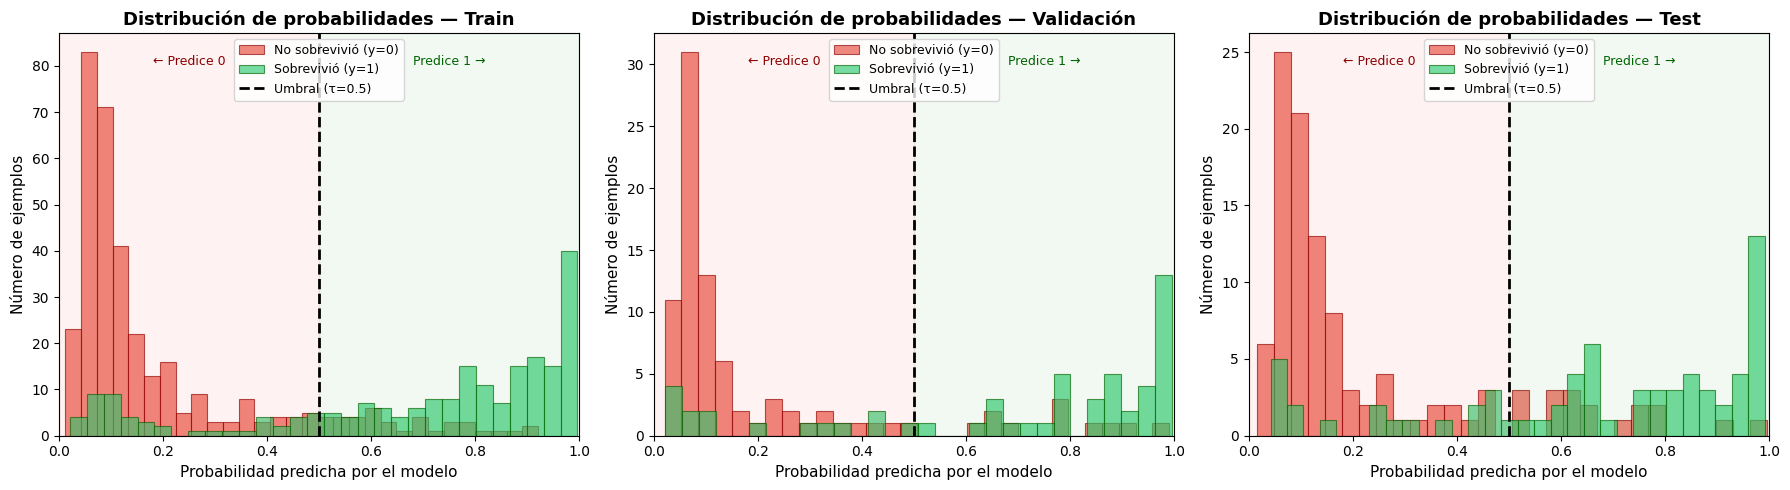

In [79]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Sacamos las probabilidades que el modelo asigna a cada ejemplo (antes de aplicar el umbral 0.5)
proba_train = model.predict_proba(X_train)
proba_val   = model.predict_proba(X_val)
proba_test  = model.predict_proba(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, proba, y_true, title in zip(
    axes,
    [proba_train, proba_val, proba_test],
    [y_train_arr, y_val_arr, y_test_arr],
    ['Train', 'Validación', 'Test']
):
    # Separamos las probabilidades según la clase real para ver si el modelo las distingue
    mask_0 = y_true == 0  # Los que NO sobrevivieron
    mask_1 = y_true == 1  # Los que SÍ sobrevivieron

    # Dibujamos un histograma para cada clase con colores bien diferenciados
    ax.hist(proba[mask_0], bins=30, alpha=0.65, color='#e74c3c', edgecolor='darkred',
            linewidth=0.8, label='No sobrevivió (y=0)')
    ax.hist(proba[mask_1], bins=30, alpha=0.65, color='#2ecc71', edgecolor='darkgreen',
            linewidth=0.8, label='Sobrevivió (y=1)')

    # Línea del umbral de decisión: a la izquierda se predice 0, a la derecha 1
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Umbral (τ=0.5)')

    # Sombreamos las zonas de decisión para que quede más claro
    ax.axvspan(0, 0.5, alpha=0.05, color='red')    # Zona donde se predice 0
    ax.axvspan(0.5, 1, alpha=0.05, color='green')   # Zona donde se predice 1

    ax.set_xlabel('Probabilidad predicha por el modelo', fontsize=11)
    ax.set_ylabel('Número de ejemplos', fontsize=11)
    ax.set_title(f'Distribución de probabilidades — {title}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper center', fontsize=9)
    ax.set_xlim(0, 1)

    # Añadimos texto con las etiquetas de las zonas de predicción
    ax.text(0.25, ax.get_ylim()[1]*0.92, '← Predice 0', ha='center', fontsize=9, color='darkred')
    ax.text(0.75, ax.get_ylim()[1]*0.92, 'Predice 1 →', ha='center', fontsize=9, color='darkgreen')

plt.tight_layout()
plt.show()